# Caso Movistar: Minería de Datos Exploratoria para Decisiones Gerenciales

## Objetivo del caso

Este notebook construye un proceso de **minería de datos exploratoria** usando la base `movistar.xlsx`.  
La idea no es entrenar modelos de Machine Learning todavía, sino aplicar una lógica de minería de datos para convertir datos crudos de clientes, conciertos, compras y consumo en **hallazgos gerenciales accionables**.

El caso se puede presentar como una situación de negocio:

> **Movistar quiere entender mejor el comportamiento de sus clientes en eventos y conciertos para mejorar segmentación comercial, diseño de promociones, estrategia de mailing, venta de boletería y consumo dentro del evento.**

El proceso seguirá una lógica tipo KDD:

1. Traducción del negocio a preguntas analíticas.  
2. Comprensión inicial de la base.  
3. Diagnóstico de calidad de datos.  
4. Exploración visual de variables clave.  
5. Construcción de variables gerenciales.  
6. Análisis de patrones por cliente, concierto y ubicación.  
7. Identificación de oportunidades estratégicas.

---

## Preguntas guía para la clase

- ¿Qué tipo de cliente compra más tickets?
- ¿Qué segmentos generan mayor ingreso total?
- ¿El mailing list parece asociado con mayor gasto o anticipación de compra?
- ¿Qué conciertos tienen mejor desempeño comercial?
- ¿Qué ubicación de asiento concentra mayor ingreso?
- ¿La compra anticipada se relaciona con precio, número de tickets o consumo en concesiones?
- ¿Qué variables podrían ser útiles más adelante para un modelo predictivo, aunque todavía no lo vamos a entrenar?

In [1]:
# ============================================================
# 0. Importar librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual general
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Mostrar más columnas en tablas
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 1. Cargar la base de datos

La base tiene información transaccional y descriptiva de clientes asociados a conciertos.  
El primer paso en minería de datos no es modelar, sino **entender qué representa cada fila** y qué unidad de análisis estamos observando.

En este caso, asumiremos inicialmente que cada fila representa una compra o registro asociado a un cliente y un concierto.

In [2]:
# ============================================================
# 1. Cargar datos
# ============================================================

file_path = Path("movistar.xlsx")

if not file_path.exists():
    # Ruta alternativa cuando se ejecuta en el entorno de ChatGPT
    file_path = Path("/mnt/data/movistar.xlsx")

df_raw = pd.read_excel(file_path)

df = df_raw.copy()

print("Dimensión de la base:", df.shape)
display(df.head())

Dimensión de la base: (1000, 11)


,customerID,customerName,Age,Fan_Mailing_List,Customer_Type,Concierto,Num_Tickets_Purchased,Seat_Location,Ticket_Price,Concession_Purchases,Days_Before_Concierto
0,84d6d15c19b7ef14,"el-Sadek, Lateefa",42,No,Last-Minute,324fd36f67eb,2,Upper,307.64,13.92,2
1,4d570962be6afdbd,"el-Shahan, Wadee'a",61,Yes,In-Between,0c4f632e4414,1,Upper,324.07,18.47,14
2,aaabe0dae9c355d2,"Legge, Megan",27,No,Last-Minute,2f73386a1b02,4,Upper,291.51,3.24,0
3,64f0b74afeb534da,"Burrows, Keenan",32,Yes,Last-Minute,0bdd7a9ec446,2,Upper,184.92,0.00,2
4,e2bef2d7b2a2de4d,"Waggoner, Lucas",34,No,Last-Minute,7040d6183039,1,Upper,198.40,0.00,1


# 2. Diccionario inicial de variables

Antes de graficar, conviene construir un inventario de variables. Esto ayuda a diferenciar:

- Variables de identificación.
- Variables sociodemográficas.
- Variables de comportamiento de compra.
- Variables comerciales.
- Variables de evento.

In [3]:
# ============================================================
# 2. Diccionario técnico inicial
# ============================================================

dictionary = pd.DataFrame({
    "variable": df.columns,
    "tipo_python": [str(df[c].dtype) for c in df.columns],
    "valores_no_nulos": [df[c].notna().sum() for c in df.columns],
    "valores_faltantes": [df[c].isna().sum() for c in df.columns],
    "% faltante": [df[c].isna().mean() * 100 for c in df.columns],
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns]
})

display(dictionary)

,variable,tipo_python,valores_no_nulos,valores_faltantes,% faltante,valores_unicos
0,customerID,object,1000,0,0.00,1000
1,customerName,object,1000,0,0.00,1000
2,Age,int64,1000,0,0.00,56
3,Fan_Mailing_List,object,1000,0,0.00,2
4,Customer_Type,object,1000,0,0.00,3
5,Concierto,object,1000,0,0.00,123
6,Num_Tickets_Purchased,int64,1000,0,0.00,10
7,Seat_Location,object,1000,0,0.00,2
8,Ticket_Price,float64,1000,0,0.00,982
9,Concession_Purchases,float64,1000,0,0.00,558


# 3. Traducción del negocio a reglas de procesamiento

En minería de datos, la limpieza no debe hacerse solo por conveniencia técnica. Debe responder a reglas de negocio.

Para este caso usaremos las siguientes reglas:

| Variable | Interpretación gerencial | Regla inicial |
|---|---|---|
| `customerID` | Identificador del cliente | No debe usarse como variable analítica directa |
| `customerName` | Nombre del cliente | Se excluye de análisis numérico por privacidad y baja utilidad predictiva |
| `Age` | Edad del cliente | Revisar rangos extremos |
| `Fan_Mailing_List` | Pertenece o no a lista de comunicación | Variable clave para estrategia comercial |
| `Customer_Type` | Tipo de cliente | Segmentación comercial |
| `Concierto` | Evento o artista | Unidad clave de análisis de demanda |
| `Num_Tickets_Purchased` | Número de tickets comprados | Intensidad de compra |
| `Seat_Location` | Ubicación del asiento | Proxy de preferencia y capacidad de pago |
| `Ticket_Price` | Precio del ticket | Ingreso por boletería |
| `Concession_Purchases` | Consumo adicional | Ingreso complementario |
| `Days_Before_Concierto` | Anticipación de compra | Planeación, urgencia y comportamiento de demanda |

In [4]:
# ============================================================
# 3. Normalización básica de nombres y categorías
# ============================================================

# Quitar espacios accidentales en nombres de columnas
# y mantener nombres originales legibles.
df.columns = [c.strip() for c in df.columns]

# Variables categóricas esperadas
categorical_cols = [
    "Fan_Mailing_List",
    "Customer_Type",
    "Concierto",
    "Seat_Location"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Variables numéricas esperadas
numeric_cols = [
    "Age",
    "Num_Tickets_Purchased",
    "Ticket_Price",
    "Concession_Purchases",
    "Days_Before_Concierto"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Tipos después de la limpieza inicial:")
print(df.dtypes)

Tipos después de la limpieza inicial:
customerID                object
customerName              object
Age                        int64
Fan_Mailing_List          object
Customer_Type             object
Concierto                 object
Num_Tickets_Purchased      int64
Seat_Location             object
Ticket_Price             float64
Concession_Purchases     float64
Days_Before_Concierto      int64
dtype: object


# 4. Diagnóstico de completitud

Esta fase responde a una pregunta básica: **¿qué tan confiable es la base antes de extraer patrones?**

Un gráfico de faltantes permite ver si existen variables con pérdida de información. En un contexto gerencial, esto no es menor: una variable incompleta puede sesgar la lectura del mercado.

,variable,porcentaje_faltante
0,customerID,0.00
1,customerName,0.00
2,Age,0.00
3,Fan_Mailing_List,0.00
4,Customer_Type,0.00
5,Concierto,0.00
6,Num_Tickets_Purchased,0.00
7,Seat_Location,0.00
8,Ticket_Price,0.00
9,Concession_Purchases,0.00


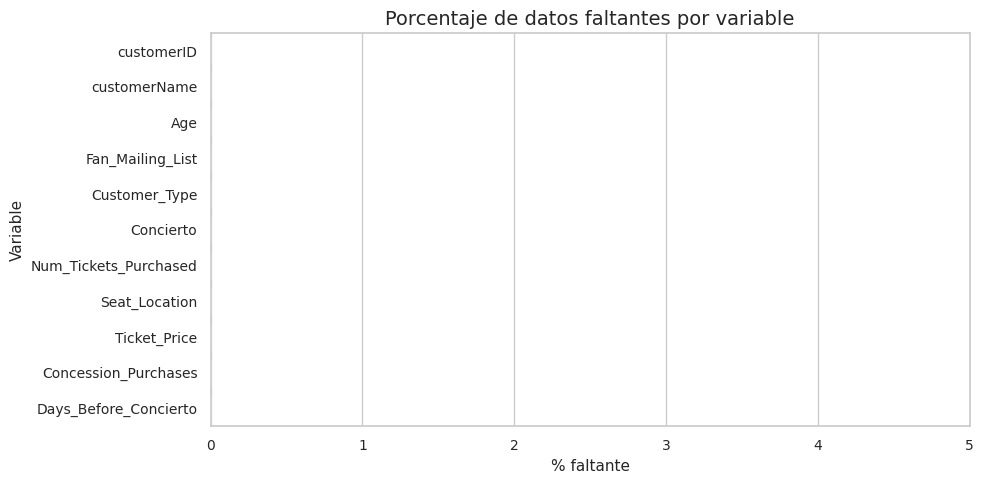

In [5]:
# ============================================================
# 4. Diagnóstico de datos faltantes
# ============================================================

missing = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing.columns = ["variable", "porcentaje_faltante"]

display(missing)

plt.figure(figsize=(10, 5))
sns.barplot(data=missing, x="porcentaje_faltante", y="variable")
plt.title("Porcentaje de datos faltantes por variable")
plt.xlabel("% faltante")
plt.ylabel("Variable")
plt.xlim(0, max(1, missing["porcentaje_faltante"].max() + 5))
plt.tight_layout()
plt.show()

# 5. Exploración univariada: ¿cómo se comporta cada variable?

La exploración univariada permite entender la forma básica de la base:

- Distribución de edades.
- Número de tickets comprados.
- Precio de tickets.
- Compras en concesiones.
- Días de anticipación de compra.

Esta etapa es fundamental porque antes de comparar grupos debemos entender los rangos y la dispersión de cada variable.

,count,mean,std,min,25%,50%,75%,max
Age,"1,000.00",43.22,11.75,18.00,34.00,43.00,51.25,76.00
Num_Tickets_Purchased,"1,000.00",2.80,1.77,1.00,1.00,2.00,4.00,10.00
Ticket_Price,"1,000.00",296.02,140.03,64.52,199.18,264.74,357.89,"1,429.17"
Concession_Purchases,"1,000.00",13.52,15.05,0.00,0.00,7.90,24.33,72.60
Days_Before_Concierto,"1,000.00",11.09,10.05,0.00,2.00,9.00,19.00,36.00


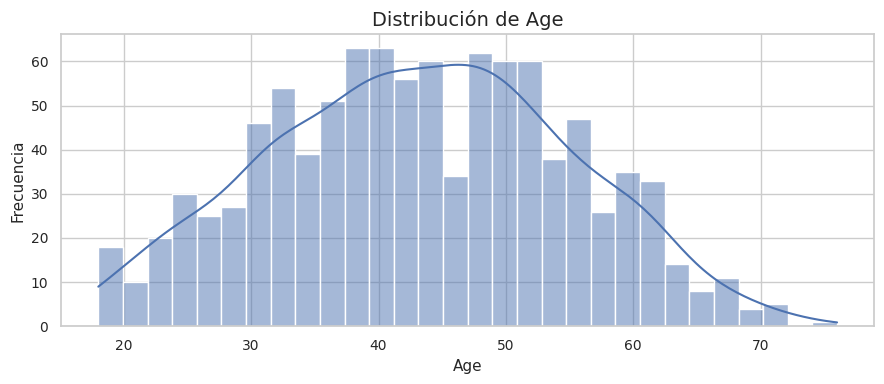

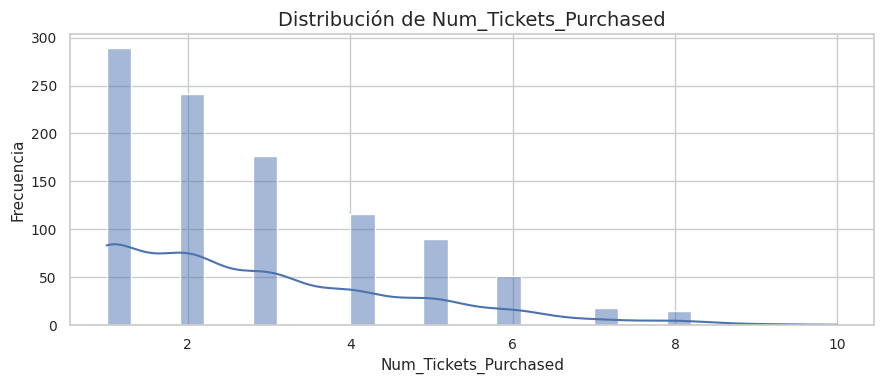

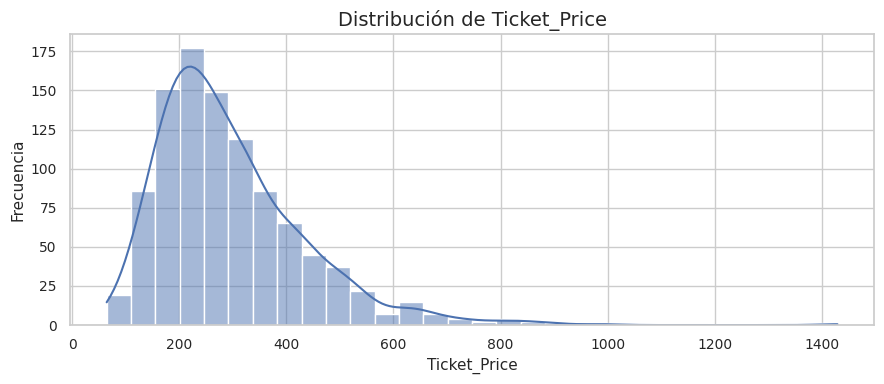

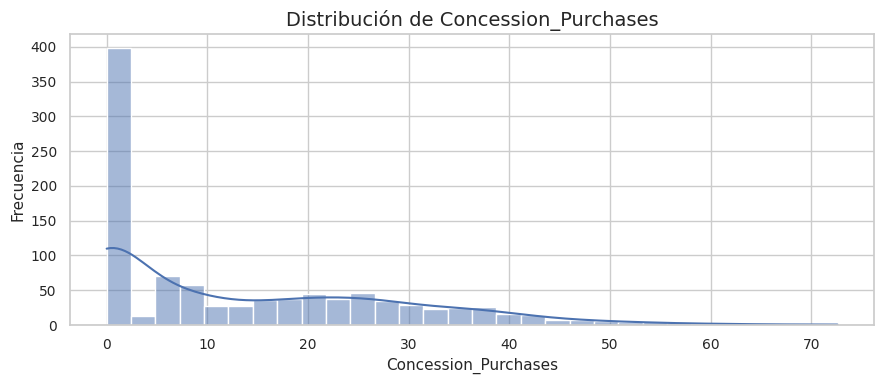

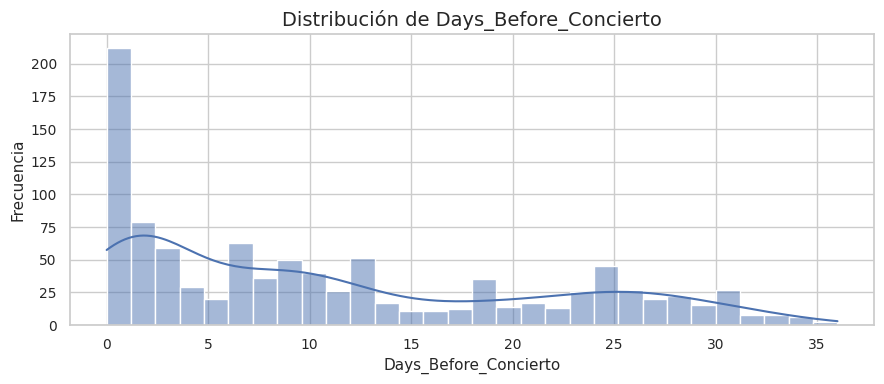

In [6]:
# ============================================================
# 5. Distribuciones numéricas generales
# ============================================================

available_numeric = [c for c in numeric_cols if c in df.columns]

display(df[available_numeric].describe().T)

for col in available_numeric:
    plt.figure(figsize=(9, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

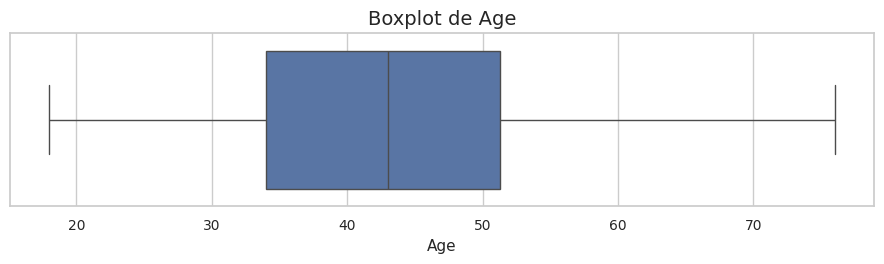

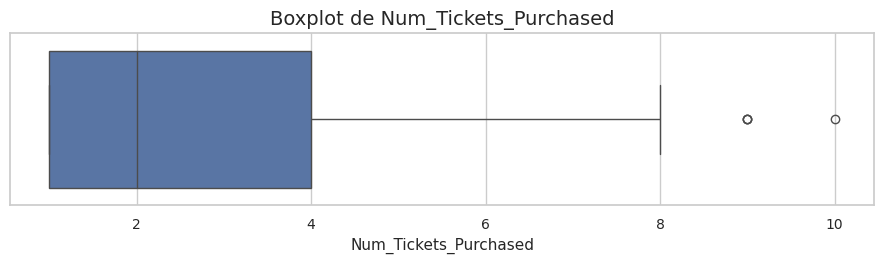

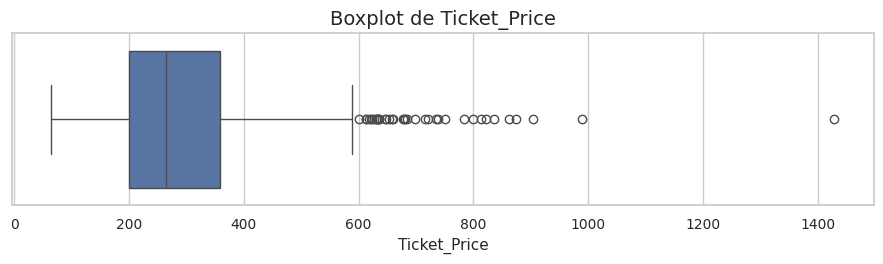

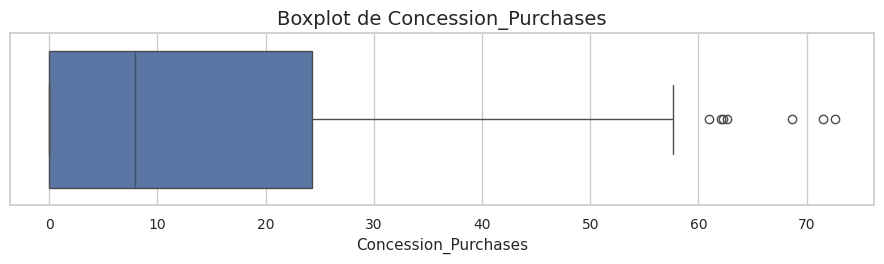

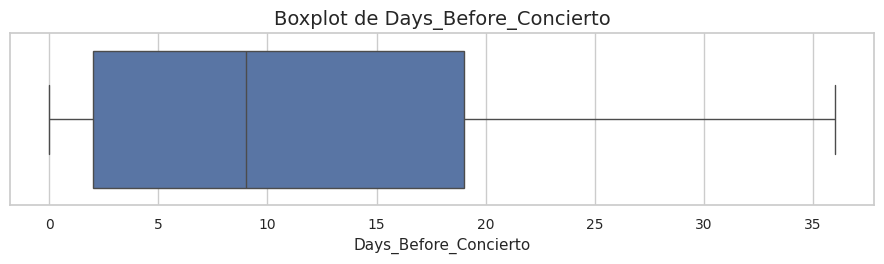

In [7]:
# ============================================================
# 6. Boxplots para detectar valores extremos
# ============================================================

for col in available_numeric:
    plt.figure(figsize=(9, 2.8))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# 6. Atípicos: ¿ruido o señal?

Un valor extremo no debe eliminarse automáticamente. En minería de datos gerencial puede representar:

- Un error de captura.
- Un cliente de alto valor.
- Una compra grupal.
- Un concierto con alta demanda.
- Una señal de comportamiento estratégico.

Por eso, el siguiente bloque identifica valores extremos por regla IQR, pero no los borra.

In [8]:
# ============================================================
# 7. Detección exploratoria de atípicos por IQR
# ============================================================

outlier_summary = []

for col in available_numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "limite_inferior": lower,
        "limite_superior": upper,
        "n_atipicos": n_outliers,
        "% atipicos": n_outliers / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

,variable,q1,q3,limite_inferior,limite_superior,n_atipicos,% atipicos
0,Age,34.00,51.25,8.12,77.12,0,0.00
1,Num_Tickets_Purchased,1.00,4.00,-3.50,8.50,4,0.40
2,Ticket_Price,199.18,357.89,-38.89,595.97,38,3.80
3,Concession_Purchases,0.00,24.33,-36.49,60.82,7,0.70
4,Days_Before_Concierto,2.00,19.00,-23.50,44.50,0,0.00


# 7. Exploración categórica

Ahora revisamos las variables que representan segmentos y decisiones comerciales:

- Pertenencia al mailing list.
- Tipo de cliente.
- Concierto.
- Ubicación del asiento.

Estas variables son claves para la estrategia porque permiten pasar de una lectura general de la base a una lectura por segmentos.

,Fan_Mailing_List,frecuencia
0,No,732
1,Yes,268


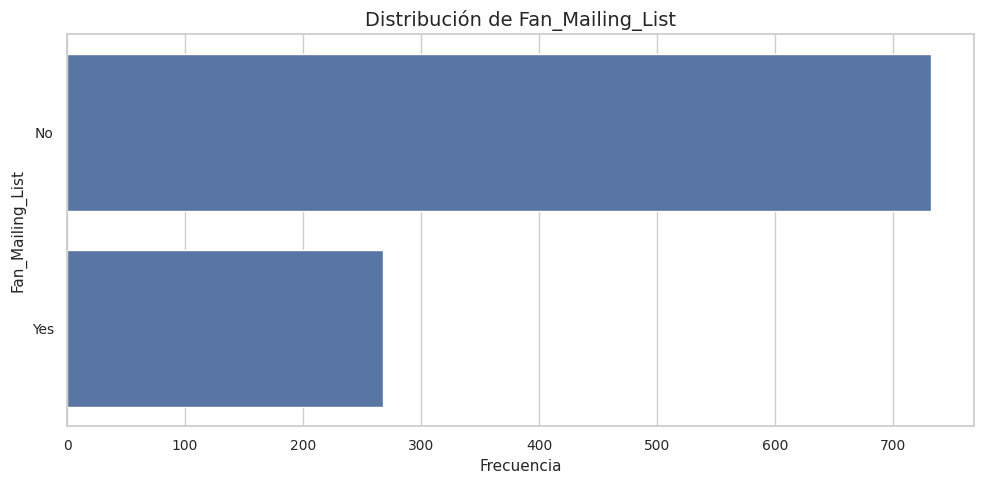

,Customer_Type,frecuencia
0,Last-Minute,368
1,In-Between,326
2,Planner,306


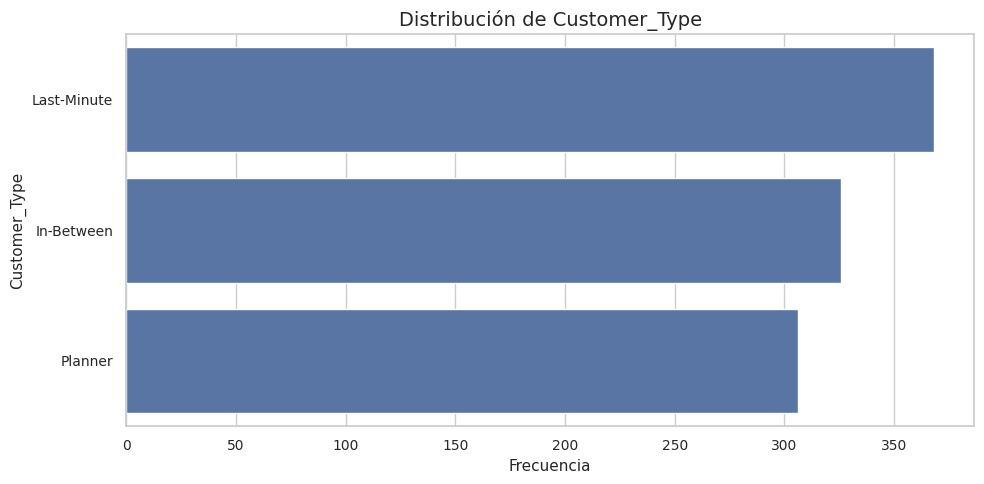

,Concierto,frecuencia
0,5e9c45374431,15
1,7fc94b0bd340,15
2,c235c4351211,15
3,695e4bcb9d6a,13
4,6302c3d0e2df,13
...,...,...
118,cee00fadd776,3
119,8c6e3539b3f3,3
120,f651f40d5461,3
121,058a96833a6d,2


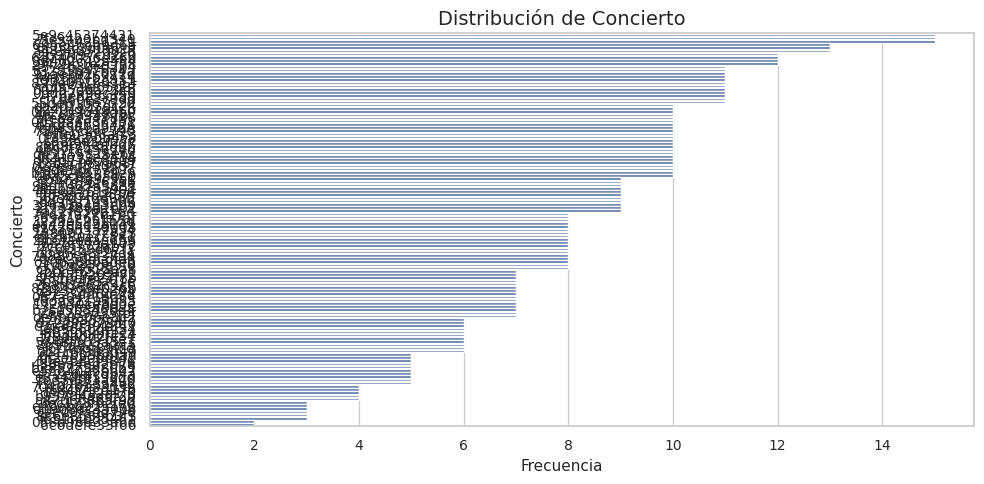

,Seat_Location,frecuencia
0,Upper,522
1,Lower,478


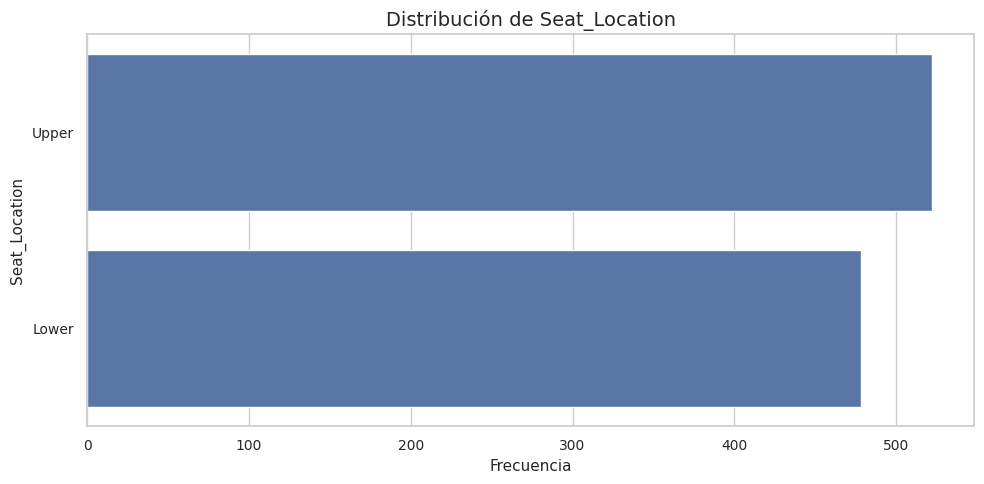

In [9]:
# ============================================================
# 8. Frecuencias de variables categóricas
# ============================================================

available_categorical = [c for c in categorical_cols if c in df.columns]

for col in available_categorical:
    freq = df[col].value_counts(dropna=False).reset_index()
    freq.columns = [col, "frecuencia"]
    display(freq)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=freq, y=col, x="frecuencia")
    plt.title(f"Distribución de {col}")
    plt.xlabel("Frecuencia")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# 8. Ingeniería de características gerenciales

En minería de datos, la ingeniería de características no es solo una tarea técnica. Es la traducción del negocio a variables analíticas.

Crearemos variables como:

- `Ticket_Revenue`: ingreso por boletería.
- `Total_Revenue`: ingreso total estimado por cliente/compra.
- `Concession_per_Ticket`: consumo adicional por ticket.
- `Purchase_Anticipation_Group`: grupo de anticipación de compra.
- `Age_Group`: segmento etario.
- `Ticket_Intensity`: intensidad de compra.

Estas variables no son modelos. Son nuevas formas de leer el negocio.

In [10]:
# ============================================================
# 9. Crear variables gerenciales
# ============================================================

# Ingreso por boletería
if {"Num_Tickets_Purchased", "Ticket_Price"}.issubset(df.columns):
    df["Ticket_Revenue"] = df["Num_Tickets_Purchased"] * df["Ticket_Price"]

# Ingreso total aproximado
if {"Ticket_Revenue", "Concession_Purchases"}.issubset(df.columns):
    df["Total_Revenue"] = df["Ticket_Revenue"] + df["Concession_Purchases"]

# Consumo de concesiones por ticket
if {"Concession_Purchases", "Num_Tickets_Purchased"}.issubset(df.columns):
    df["Concession_per_Ticket"] = np.where(
        df["Num_Tickets_Purchased"] > 0,
        df["Concession_Purchases"] / df["Num_Tickets_Purchased"],
        np.nan
    )

# Segmentos de edad
if "Age" in df.columns:
    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=[0, 24, 34, 44, 54, 64, 120],
        labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
        include_lowest=True
    )

# Segmentos de anticipación de compra
if "Days_Before_Concierto" in df.columns:
    df["Purchase_Anticipation_Group"] = pd.cut(
        df["Days_Before_Concierto"],
        bins=[-1, 0, 3, 7, 14, 30, 365],
        labels=["Mismo día", "1-3 días", "4-7 días", "8-14 días", "15-30 días", "+30 días"]
    )

# Intensidad de compra
if "Num_Tickets_Purchased" in df.columns:
    df["Ticket_Intensity"] = pd.cut(
        df["Num_Tickets_Purchased"],
        bins=[0, 1, 2, 4, 100],
        labels=["Individual", "Pareja", "Grupo pequeño", "Grupo grande"],
        include_lowest=True
    )

new_features = [
    "Ticket_Revenue", "Total_Revenue", "Concession_per_Ticket",
    "Age_Group", "Purchase_Anticipation_Group", "Ticket_Intensity"
]

available_new_features = [c for c in new_features if c in df.columns]

display(df[available_new_features].head())

,Ticket_Revenue,Total_Revenue,Concession_per_Ticket,Age_Group,Purchase_Anticipation_Group,Ticket_Intensity
0,615.28,629.20,6.96,35-44,1-3 días,Pareja
1,324.07,342.54,18.47,55-64,8-14 días,Individual
2,"1,166.04","1,169.28",0.81,25-34,Mismo día,Grupo pequeño
3,369.84,369.84,0.00,25-34,1-3 días,Pareja
4,198.40,198.40,0.00,25-34,1-3 días,Individual


# 9. Lectura gerencial del ingreso

La primera dimensión estratégica es el ingreso. No basta con mirar cuántas personas compran, también importa:

- Cuánto pagan por ticket.
- Cuántos tickets compran.
- Cuánto consumen adicionalmente.
- Qué segmento concentra más valor.

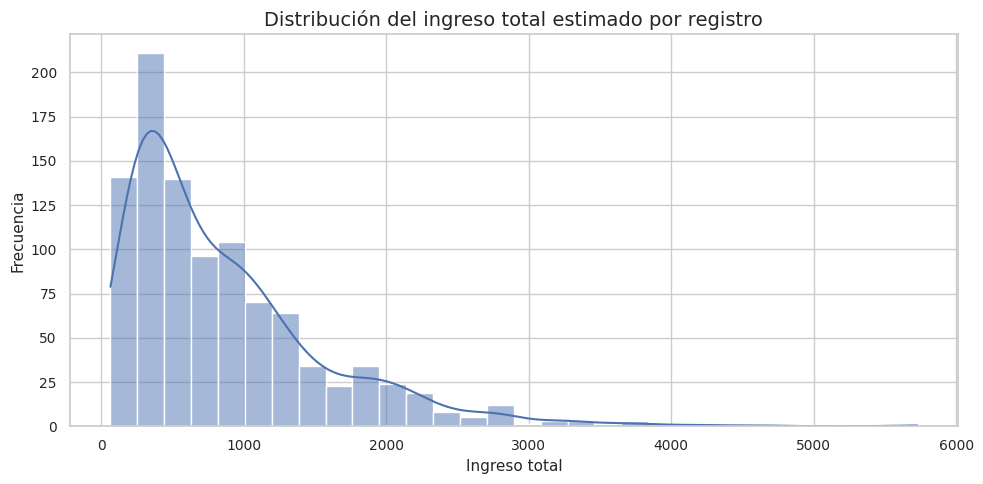

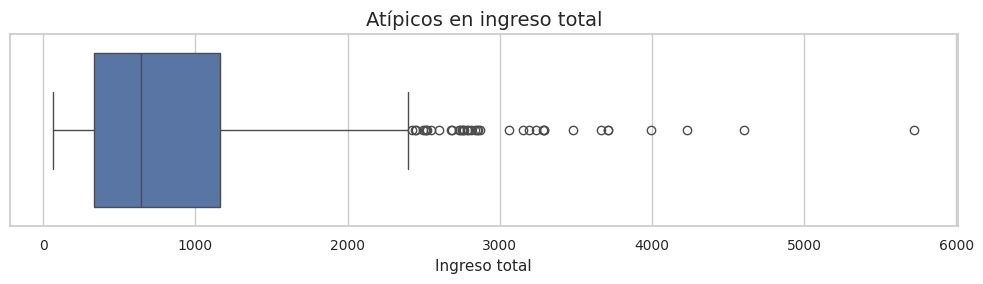

In [11]:
# ============================================================
# 10. Distribución del ingreso total
# ============================================================

if "Total_Revenue" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df["Total_Revenue"], kde=True, bins=30)
    plt.title("Distribución del ingreso total estimado por registro")
    plt.xlabel("Ingreso total")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3))
    sns.boxplot(data=df, x="Total_Revenue")
    plt.title("Atípicos en ingreso total")
    plt.xlabel("Ingreso total")
    plt.tight_layout()
    plt.show()

,Customer_Type,count,mean,median,sum
0,Planner,306,"1,342.37","1,099.52","410,765.92"
1,In-Between,326,917.45,804.30,"299,088.18"
2,Last-Minute,368,401.93,319.14,"147,908.58"


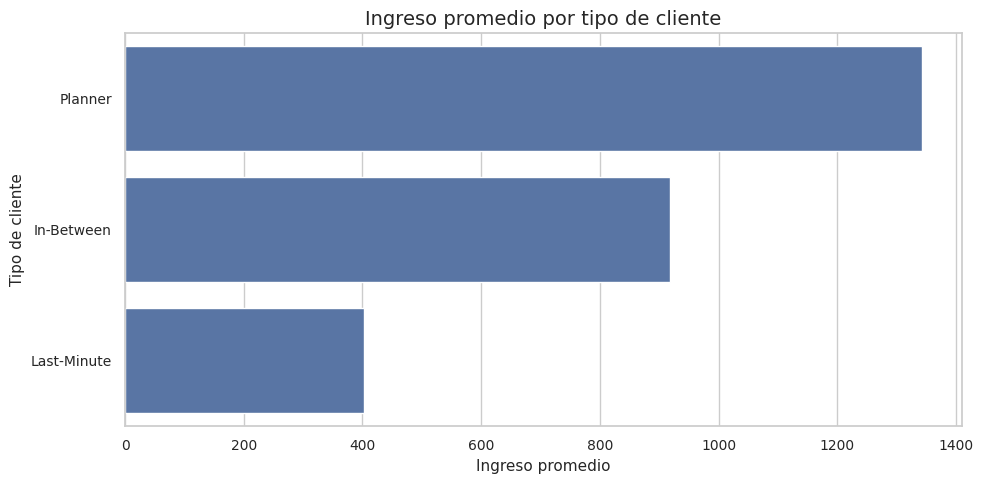

In [12]:
# ============================================================
# 11. Ingreso promedio por tipo de cliente
# ============================================================

if {"Customer_Type", "Total_Revenue"}.issubset(df.columns):
    revenue_by_customer = (
        df.groupby("Customer_Type", observed=False)["Total_Revenue"]
        .agg(["count", "mean", "median", "sum"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    display(revenue_by_customer)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=revenue_by_customer, y="Customer_Type", x="mean")
    plt.title("Ingreso promedio por tipo de cliente")
    plt.xlabel("Ingreso promedio")
    plt.ylabel("Tipo de cliente")
    plt.tight_layout()
    plt.show()

,Concierto,count,mean,median,sum
0,6a746056e26b,12,"1,152.18",713.85,"13,826.19"
1,4b97f845624d,10,"1,379.48",985.84,"13,794.84"
2,9429b1e2cf58,12,"1,101.51",506.40,"13,218.12"
3,c235c4351211,15,836.71,481.90,"12,550.63"
4,0f394c70b4c8,10,"1,214.30",932.87,"12,143.00"
...,...,...,...,...,...
118,e55640e5bb47,5,462.24,207.78,"2,311.20"
119,cee00fadd776,3,710.71,290.27,"2,132.12"
120,7040d6183039,4,311.88,340.48,"1,247.53"
121,6c6defe33f66,2,580.38,580.38,"1,160.77"


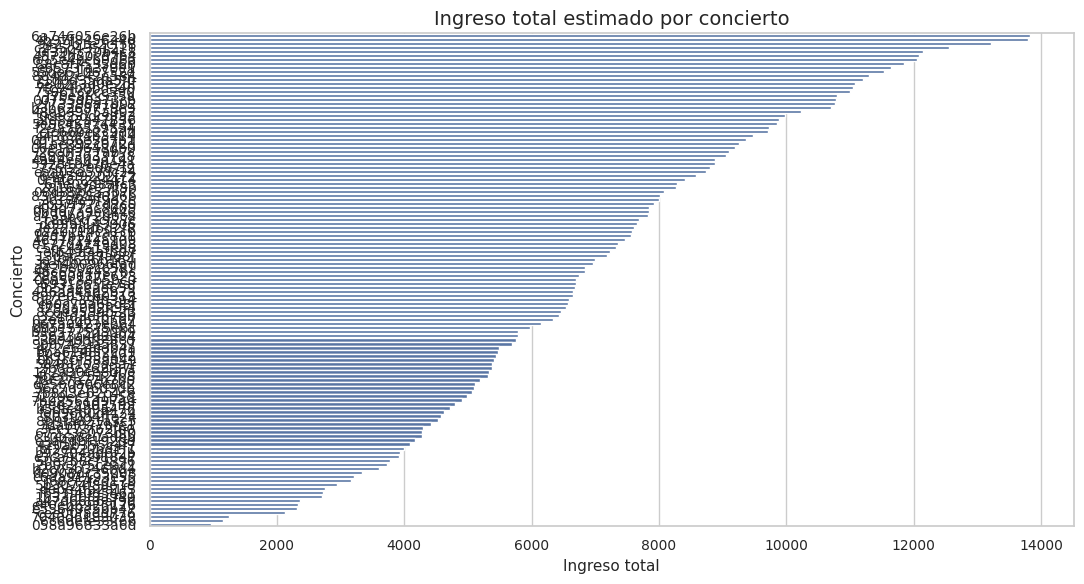

In [13]:
# ============================================================
# 12. Ingreso por concierto
# ============================================================

if {"Concierto", "Total_Revenue"}.issubset(df.columns):
    revenue_by_concert = (
        df.groupby("Concierto", observed=False)["Total_Revenue"]
        .agg(["count", "mean", "median", "sum"])
        .sort_values("sum", ascending=False)
        .reset_index()
    )
    display(revenue_by_concert)

    plt.figure(figsize=(11, 6))
    sns.barplot(data=revenue_by_concert, y="Concierto", x="sum")
    plt.title("Ingreso total estimado por concierto")
    plt.xlabel("Ingreso total")
    plt.ylabel("Concierto")
    plt.tight_layout()
    plt.show()

# 10. Mailing list como variable estratégica

El mailing list puede interpretarse como un canal de relación directa con el cliente.  
En este EDA no vamos a afirmar causalidad, pero sí podemos explorar si quienes están en la lista muestran diferencias en:

- Anticipación de compra.
- Número de tickets.
- Ingreso total.
- Consumo de concesiones.

,Fan_Mailing_List,Age,Num_Tickets_Purchased,Ticket_Price,Concession_Purchases,Days_Before_Concierto,Ticket_Revenue,Total_Revenue,Concession_per_Ticket
0,No,41.15,2.58,290.47,11.54,8.95,766.18,777.72,4.78
1,Yes,48.85,3.40,311.16,18.93,16.91,"1,057.47","1,076.40",6.59


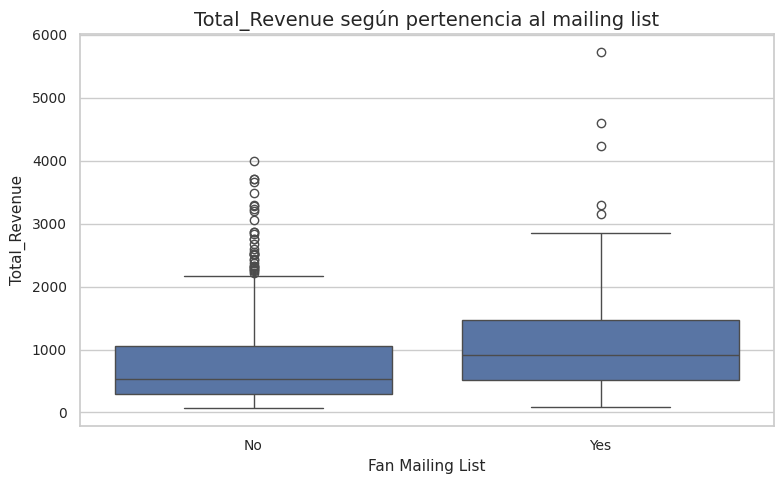

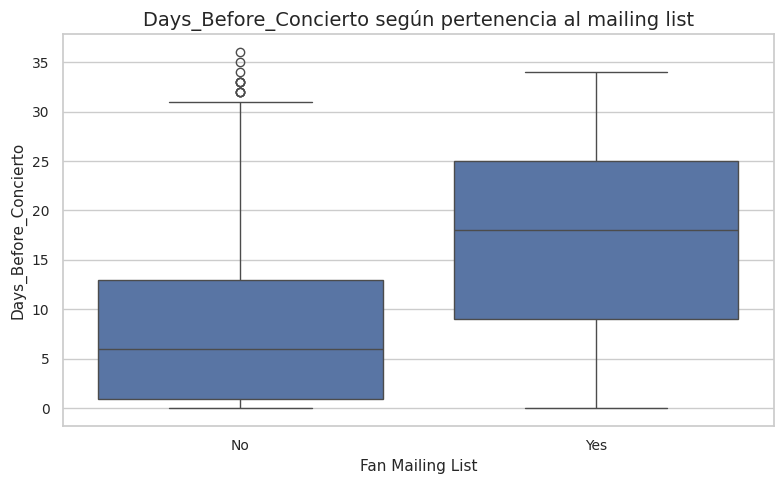

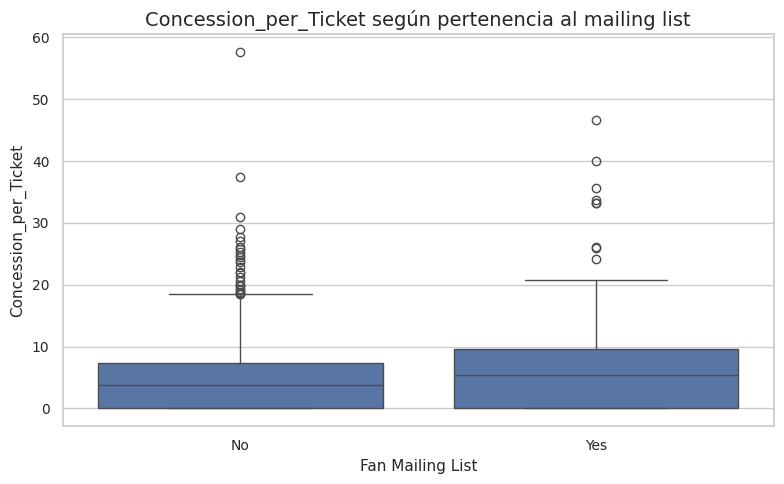

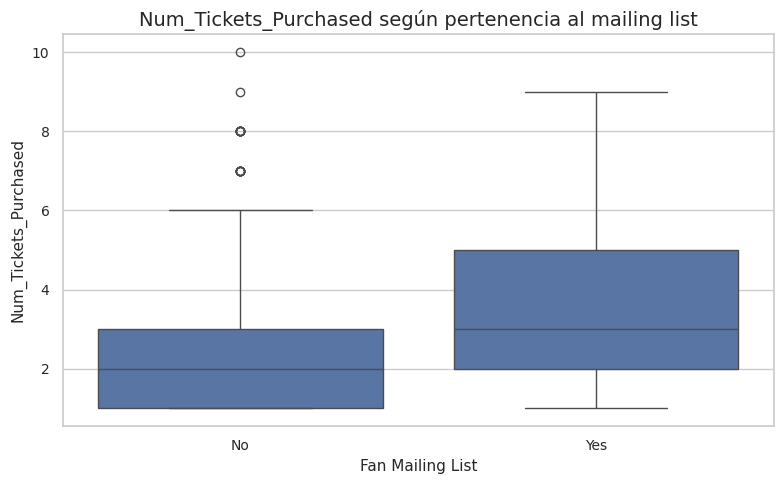

In [14]:
# ============================================================
# 13. Comparación por Fan Mailing List
# ============================================================

if "Fan_Mailing_List" in df.columns:
    mailing_metrics = [
        c for c in [
            "Age", "Num_Tickets_Purchased", "Ticket_Price",
            "Concession_Purchases", "Days_Before_Concierto",
            "Ticket_Revenue", "Total_Revenue", "Concession_per_Ticket"
        ] if c in df.columns
    ]

    mailing_summary = (
        df.groupby("Fan_Mailing_List", observed=False)[mailing_metrics]
        .mean(numeric_only=True)
        .reset_index()
    )
    display(mailing_summary)

    for metric in ["Total_Revenue", "Days_Before_Concierto", "Concession_per_Ticket", "Num_Tickets_Purchased"]:
        if metric in df.columns:
            plt.figure(figsize=(8, 5))
            sns.boxplot(data=df, x="Fan_Mailing_List", y=metric)
            plt.title(f"{metric} según pertenencia al mailing list")
            plt.xlabel("Fan Mailing List")
            plt.ylabel(metric)
            plt.tight_layout()
            plt.show()

# 11. Ubicación del asiento y lectura de valor

La ubicación del asiento puede capturar preferencias, presupuesto y disposición a pagar.  
Este análisis permite discutir si ciertos asientos concentran más ingreso o mayor consumo complementario.

Ticket_Price                          Total_Revenue           \
                     count   mean median        sum         count     mean   
Seat_Location                                                                
Lower                  478 353.11 322.31 168,787.24           478 1,166.85   
Upper                  522 243.73 217.93 127,228.50           522   574.72   

                                Concession_Purchases                        \
              median        sum                count  mean median      sum   
Seat_Location                                                                
Lower         989.12 557,756.27                  478 17.77  17.73 8,494.97   
Upper         409.51 300,006.41                  522  9.63   5.89 5,024.69   

              Num_Tickets_Purchased                    
                              count mean median   sum  
Seat_Location                                          
Lower                           478 3.32   3.00  1585  
Upper                           522 2.33   2.00  1217

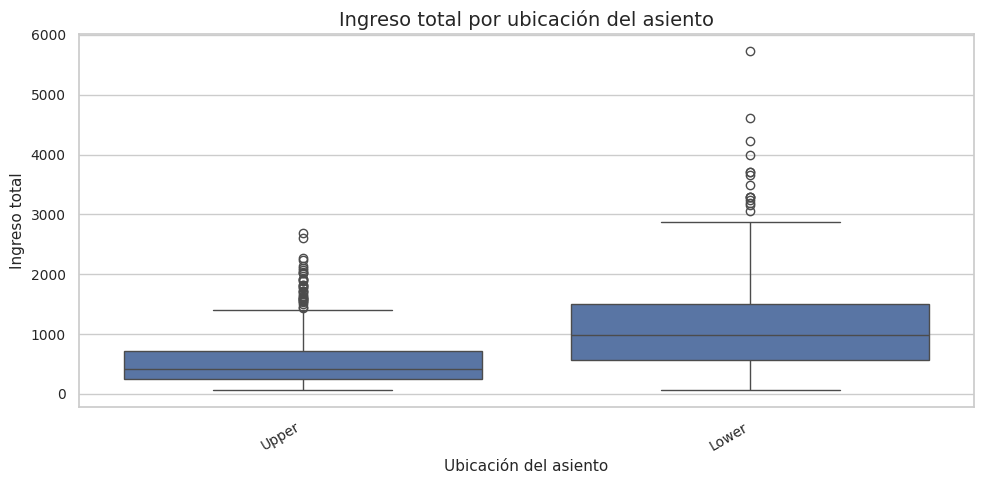

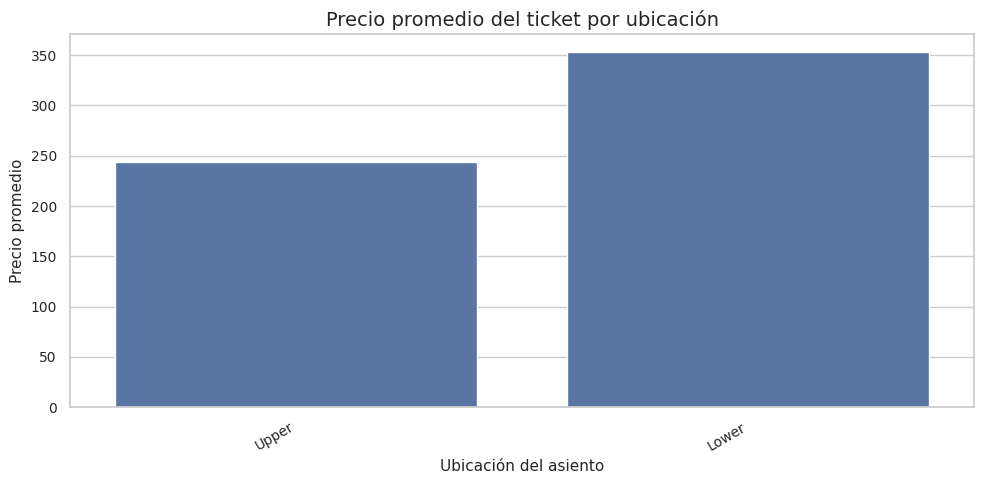

In [15]:
# ============================================================
# 14. Análisis por ubicación del asiento
# ============================================================

if "Seat_Location" in df.columns:
    seat_metrics = [c for c in ["Ticket_Price", "Total_Revenue", "Concession_Purchases", "Num_Tickets_Purchased"] if c in df.columns]
    seat_summary = (
        df.groupby("Seat_Location", observed=False)[seat_metrics]
        .agg(["count", "mean", "median", "sum"])
    )
    display(seat_summary)

    if "Total_Revenue" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x="Seat_Location", y="Total_Revenue")
        plt.title("Ingreso total por ubicación del asiento")
        plt.xlabel("Ubicación del asiento")
        plt.ylabel("Ingreso total")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    if "Ticket_Price" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=df, x="Seat_Location", y="Ticket_Price", estimator="mean", errorbar=None)
        plt.title("Precio promedio del ticket por ubicación")
        plt.xlabel("Ubicación del asiento")
        plt.ylabel("Precio promedio")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

# 12. Anticipación de compra

La anticipación de compra ayuda a entender la planeación de la demanda.  
Desde la gerencia, esto puede informar campañas tempranas, precios dinámicos, promociones y estrategia de comunicación.

,Grupo de anticipación,frecuencia
0,15-30 días,282
1,1-3 días,266
2,8-14 días,220
3,4-7 días,112
4,Mismo día,84
5,+30 días,36


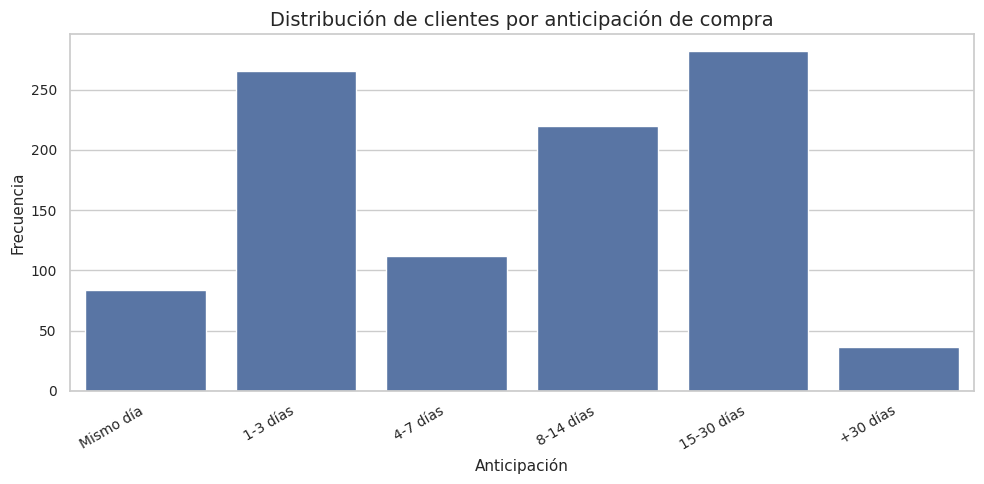

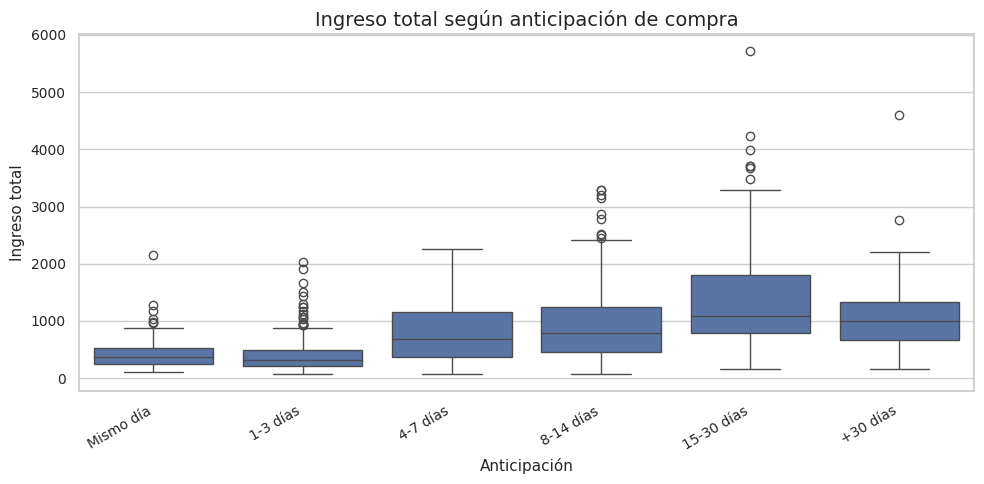

In [16]:
# ============================================================
# 15. Anticipación de compra
# ============================================================

if "Purchase_Anticipation_Group" in df.columns:
    anticipation_counts = (
        df["Purchase_Anticipation_Group"]
        .value_counts(dropna=False)
        .reset_index()
    )
    anticipation_counts.columns = ["Grupo de anticipación", "frecuencia"]
    display(anticipation_counts)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=anticipation_counts, x="Grupo de anticipación", y="frecuencia")
    plt.title("Distribución de clientes por anticipación de compra")
    plt.xlabel("Anticipación")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    if "Total_Revenue" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x="Purchase_Anticipation_Group", y="Total_Revenue")
        plt.title("Ingreso total según anticipación de compra")
        plt.xlabel("Anticipación")
        plt.ylabel("Ingreso total")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

# 13. Segmentos de edad

La edad permite crear una primera lectura de perfiles de audiencia.  
El objetivo no es estereotipar clientes, sino identificar patrones que ayuden a diseñar experiencias, comunicaciones y paquetes comerciales.

,Age_Group,clientes,edad_promedio,tickets_promedio,ingreso_promedio,concesiones_promedio
0,18-24,67,21.54,1.33,366.70,3.41
1,25-34,186,30.37,1.80,496.63,5.03
2,35-44,277,39.76,2.54,772.54,11.01
3,45-54,286,49.06,3.42,"1,089.53",17.99
4,55-64,155,58.74,3.65,"1,135.22",22.29
5,65+,29,68.14,4.45,"1,353.92",24.30


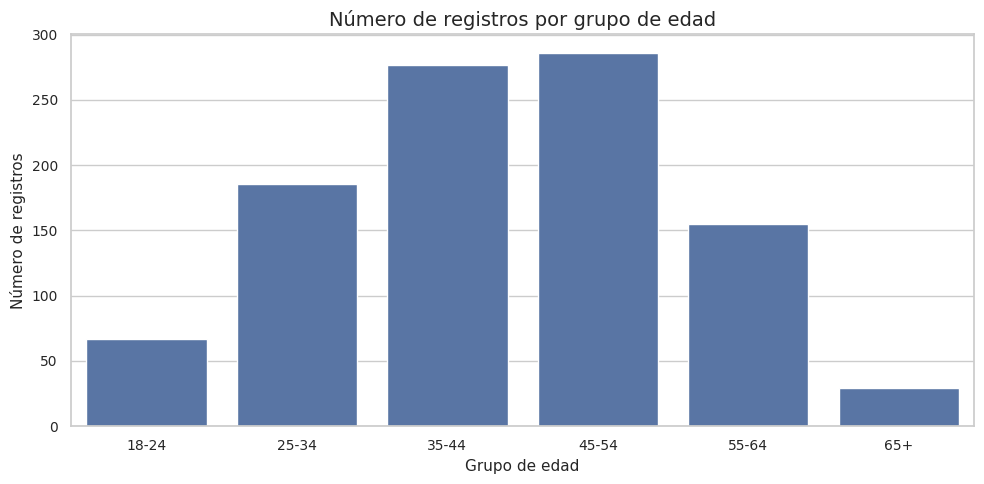

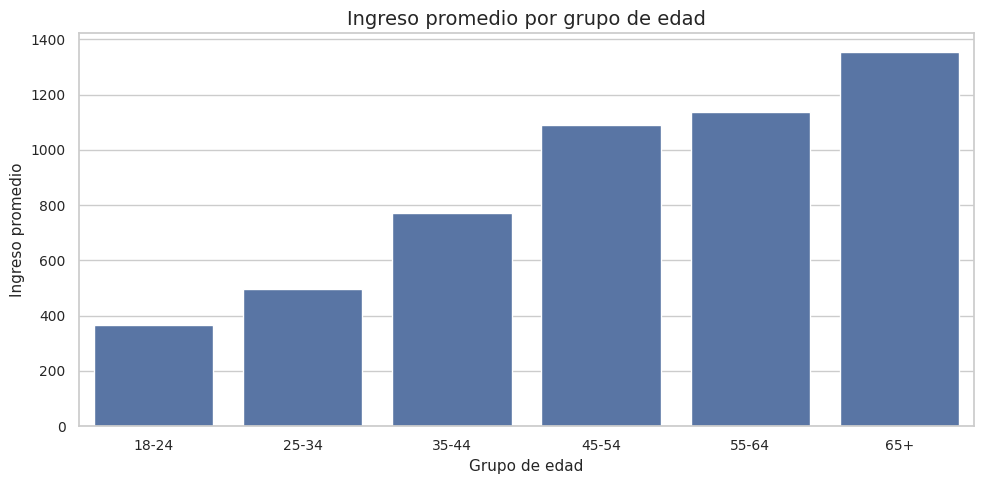

In [17]:
# ============================================================
# 16. Análisis por grupos de edad
# ============================================================

if "Age_Group" in df.columns:
    age_summary = (
        df.groupby("Age_Group", observed=False)
        .agg(
            clientes=("customerID", "count") if "customerID" in df.columns else ("Age", "count"),
            edad_promedio=("Age", "mean"),
            tickets_promedio=("Num_Tickets_Purchased", "mean") if "Num_Tickets_Purchased" in df.columns else ("Age", "mean"),
            ingreso_promedio=("Total_Revenue", "mean") if "Total_Revenue" in df.columns else ("Age", "mean"),
            concesiones_promedio=("Concession_Purchases", "mean") if "Concession_Purchases" in df.columns else ("Age", "mean")
        )
        .reset_index()
    )
    display(age_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=age_summary, x="Age_Group", y="clientes")
    plt.title("Número de registros por grupo de edad")
    plt.xlabel("Grupo de edad")
    plt.ylabel("Número de registros")
    plt.tight_layout()
    plt.show()

    if "Total_Revenue" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=age_summary, x="Age_Group", y="ingreso_promedio")
        plt.title("Ingreso promedio por grupo de edad")
        plt.xlabel("Grupo de edad")
        plt.ylabel("Ingreso promedio")
        plt.tight_layout()
        plt.show()

# 14. Relaciones entre variables numéricas

Esta sección explora relaciones entre variables sin afirmar causalidad.  
Buscamos patrones como:

- Mayor anticipación asociada con mayor o menor gasto.
- Mayor número de tickets asociado con más consumo en concesiones.
- Precio del ticket y consumo adicional.

,Age,Num_Tickets_Purchased,Ticket_Price,Concession_Purchases,Days_Before_Concierto,Ticket_Revenue,Total_Revenue,Concession_per_Ticket
Age,1.00,0.46,0.12,0.43,0.69,0.39,0.39,0.24
Num_Tickets_Purchased,0.46,1.00,0.06,0.38,0.56,0.78,0.78,-0.11
Ticket_Price,0.12,0.06,1.00,0.11,0.12,0.59,0.58,0.09
Concession_Purchases,0.43,0.38,0.11,1.00,0.53,0.34,0.36,0.73
Days_Before_Concierto,0.69,0.56,0.12,0.53,1.00,0.48,0.49,0.29
Ticket_Revenue,0.39,0.78,0.59,0.34,0.48,1.00,1.00,-0.05
Total_Revenue,0.39,0.78,0.58,0.36,0.49,1.00,1.00,-0.03
Concession_per_Ticket,0.24,-0.11,0.09,0.73,0.29,-0.05,-0.03,1.00


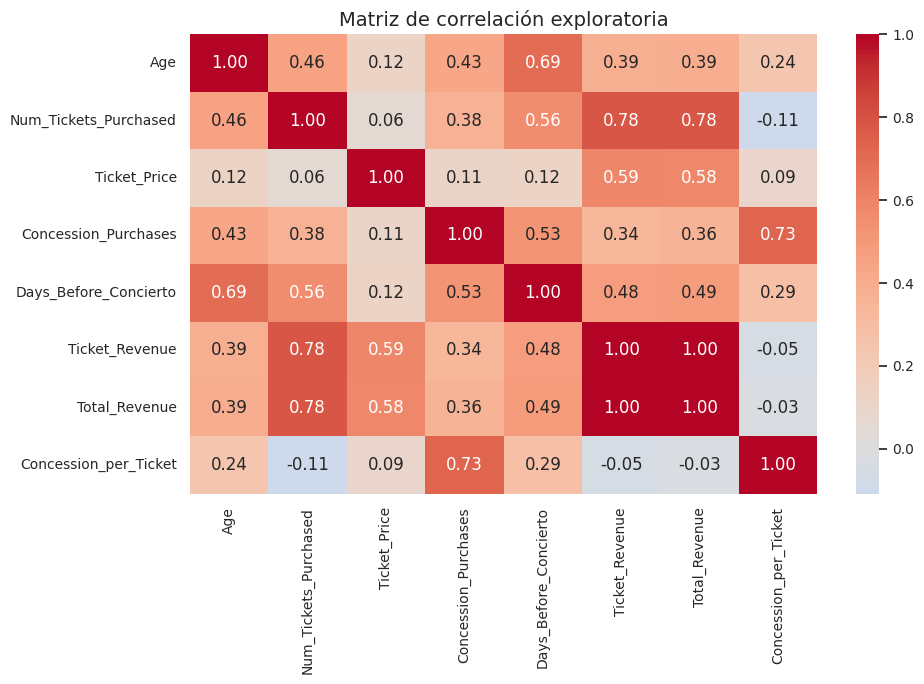

In [18]:
# ============================================================
# 17. Matriz de correlación exploratoria
# ============================================================

eda_numeric = [
    c for c in [
        "Age", "Num_Tickets_Purchased", "Ticket_Price", "Concession_Purchases",
        "Days_Before_Concierto", "Ticket_Revenue", "Total_Revenue", "Concession_per_Ticket"
    ] if c in df.columns
]

corr = df[eda_numeric].corr(numeric_only=True)

display(corr)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación exploratoria")
plt.tight_layout()
plt.show()

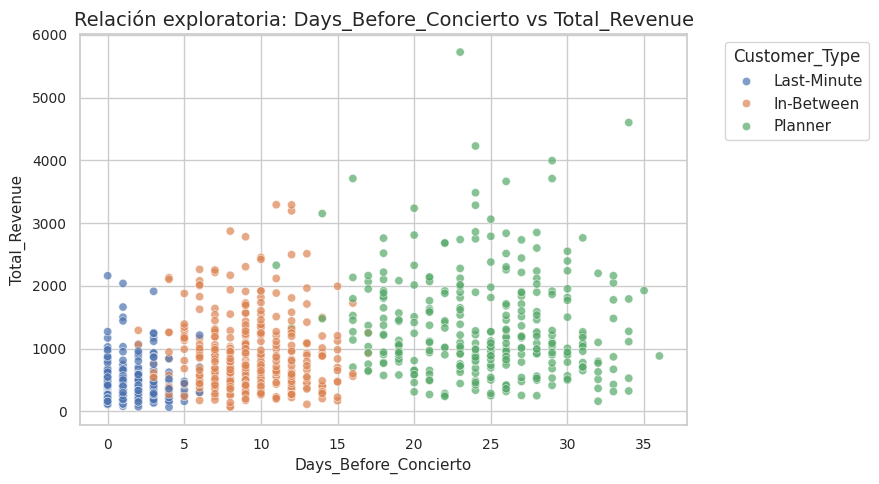

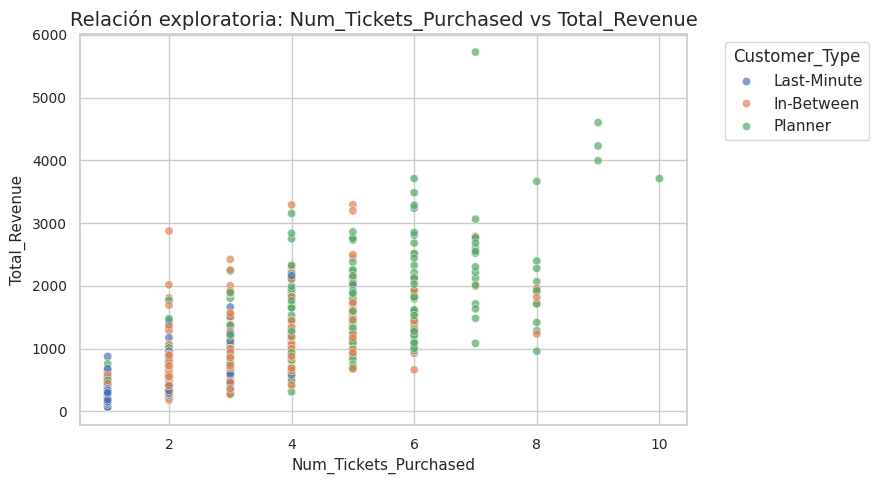

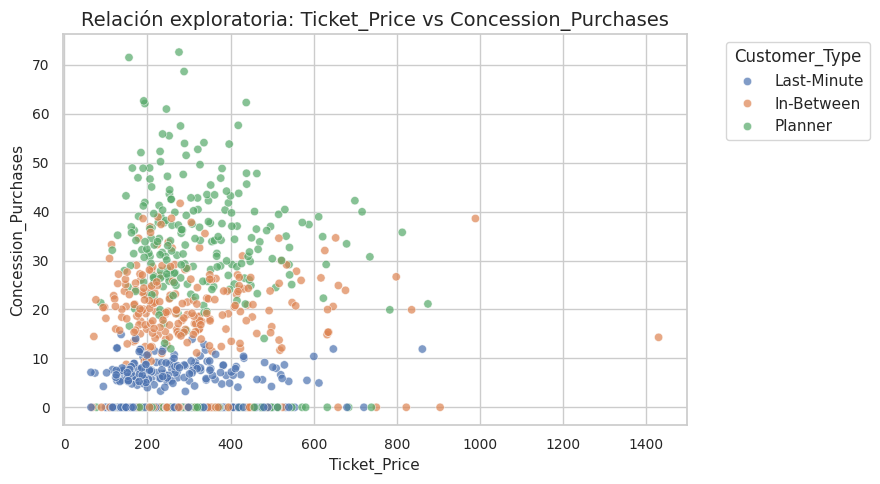

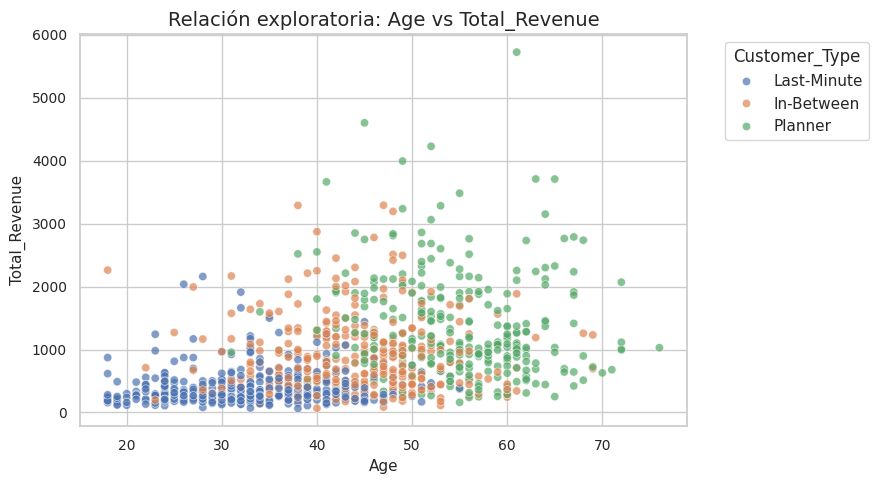

In [19]:
# ============================================================
# 18. Scatterplots estratégicos
# ============================================================

scatter_pairs = [
    ("Days_Before_Concierto", "Total_Revenue"),
    ("Num_Tickets_Purchased", "Total_Revenue"),
    ("Ticket_Price", "Concession_Purchases"),
    ("Age", "Total_Revenue")
]

for x, y in scatter_pairs:
    if {x, y}.issubset(df.columns):
        plt.figure(figsize=(9, 5))
        hue_col = "Customer_Type" if "Customer_Type" in df.columns else None
        sns.scatterplot(data=df, x=x, y=y, hue=hue_col, alpha=0.7)
        plt.title(f"Relación exploratoria: {x} vs {y}")
        plt.xlabel(x)
        plt.ylabel(y)
        if hue_col:
            plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

# 15. Heatmaps gerenciales

Los heatmaps permiten cruzar dos dimensiones de negocio.  
Son especialmente útiles para gerencia porque muestran dónde se concentra el valor.

Ejemplos:

- Concierto vs ubicación del asiento.
- Tipo de cliente vs concierto.
- Mailing list vs tipo de cliente.

Seat_Location,Lower,Upper
Concierto,,
00755d0a73cb,"1,091.27",784.65
02ee3db305d7,802.25,522.00
058a96833a6d,NaN,483.83
067a0421eb64,"1,042.92",465.45
06a5c88b5bc0,624.34,699.57
...,...,...
f651f40d5461,"1,208.81",308.18
f68cf7fcd17b,946.70,324.30
f79da0d2fc54,944.67,"1,119.88"


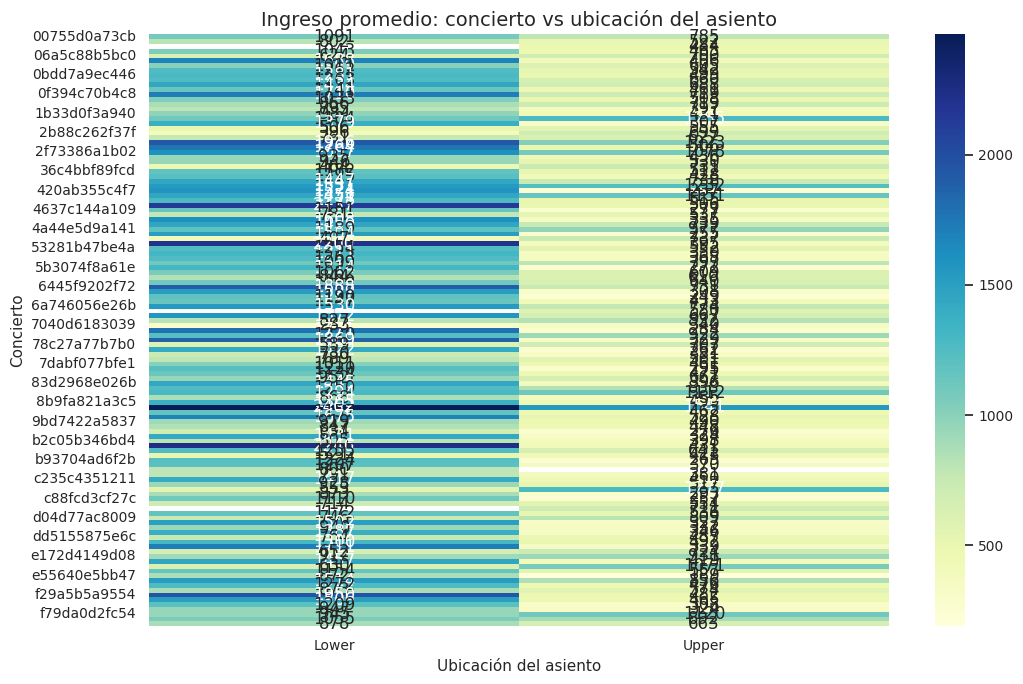

In [20]:
# ============================================================
# 19. Heatmap: ingreso promedio por concierto y ubicación
# ============================================================

if {"Concierto", "Seat_Location", "Total_Revenue"}.issubset(df.columns):
    pivot_concert_seat = df.pivot_table(
        index="Concierto",
        columns="Seat_Location",
        values="Total_Revenue",
        aggfunc="mean",
        observed=False
    )

    display(pivot_concert_seat)

    plt.figure(figsize=(11, 7))
    sns.heatmap(pivot_concert_seat, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title("Ingreso promedio: concierto vs ubicación del asiento")
    plt.xlabel("Ubicación del asiento")
    plt.ylabel("Concierto")
    plt.tight_layout()
    plt.show()

Concierto,00755d0a73cb,02ee3db305d7,058a96833a6d,067a0421eb64,06a5c88b5bc0,06e1b9648db0,08d85bc53b7c,0b1c0f38a049,0bdd7a9ec446,0c4f632e4414,0cec5ddcdfa3,0d1986e367b1,0f394c70b4c8,13dac987a68f,172a30ce8d0e,19d1b5c2c831,1b33d0f3a940,2816afe27f8b,28800117c623,2b0c275ceac1,2b88c262f37f,2b97f97cd2c0,2cc0f777ab7c,2ee2a9035fbf,2f73386a1b02,...,cee00fadd776,cfc660e2c9dd,d04d77ac8009,d0908dc35008,d240114ca1cb,d323c39fb394,dd5155875e6c,dd9faf143906,de5b0a06e8c2,debe4fa2a1f3,e172d4149d08,e3a4dbf192dd,e40eb6925176,e42b80ecc581,e55640e5bb47,e6573fa3c9e1,eaa02a53dc24,efb49f4afb07,f29a5b5a9554,f3cd7383a4e2,f651f40d5461,f68cf7fcd17b,f79da0d2fc54,f7be8fcccf5a,feb9660df424
Customer_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
In-Between,924.33,801.08,NaN,"1,109.41","1,003.22",936.19,711.96,722.43,"1,281.06",950.41,"1,203.29",908.55,"1,149.51",724.80,537.86,809.21,839.48,"1,344.14",NaN,289.91,620.99,679.90,"1,040.33",782.90,"1,428.56",...,"1,626.21",830.15,610.39,"2,251.65",964.35,"1,158.24",774.61,643.49,374.52,652.43,763.60,947.48,254.66,"1,033.56",NaN,907.34,626.71,941.03,NaN,459.69,"1,208.81",887.06,"1,057.27",988.16,422.25
Last-Minute,580.64,202.70,314.75,465.45,263.45,204.71,339.03,"1,171.35",295.15,491.13,NaN,228.75,410.25,352.65,393.94,414.26,201.90,582.25,494.00,583.27,282.39,273.88,260.66,314.78,773.91,...,252.95,427.87,291.17,327.08,331.61,345.70,373.62,220.50,405.24,200.21,964.89,338.03,"1,070.64",391.71,357.01,NaN,379.77,454.63,481.96,358.19,308.18,NaN,468.18,644.67,220.20
Planner,"1,183.79",826.15,652.92,776.97,444.16,"1,610.72","1,232.63",812.81,"1,112.36","1,090.97","1,273.70","1,372.77","2,104.73","2,514.98","1,533.84","1,122.76",414.54,"1,440.77","1,890.85",529.84,"1,770.35","1,229.77","1,557.50","1,145.95","1,271.69",...,NaN,"1,425.77","1,085.52",751.82,792.38,"1,463.32","1,013.26","1,790.41","1,560.23","1,248.64","1,603.08","1,600.10","1,006.12","1,533.82",883.17,"1,778.74","1,698.52",797.76,"1,950.07","3,710.52",NaN,759.11,"1,746.59","1,139.83","1,185.92"


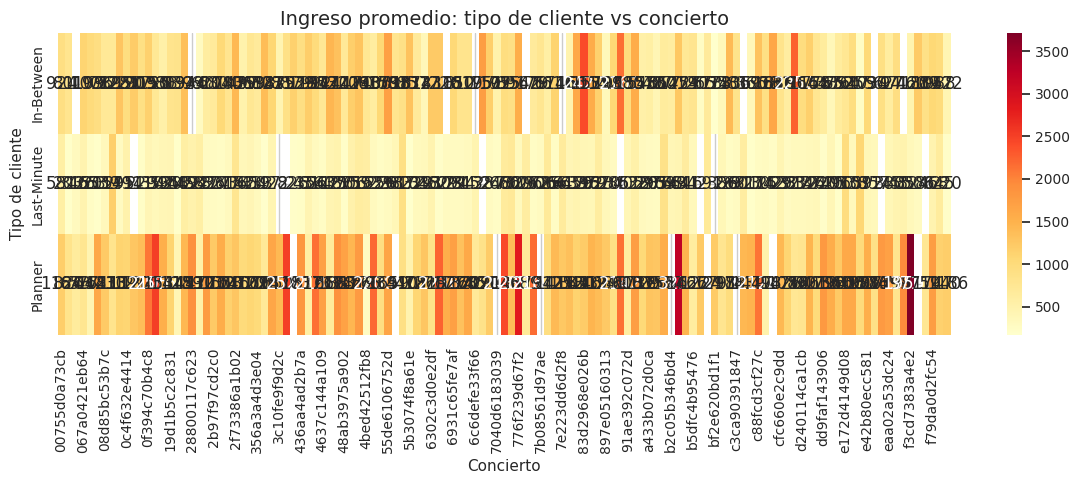

In [21]:
# ============================================================
# 20. Heatmap: ingreso promedio por tipo de cliente y concierto
# ============================================================

if {"Customer_Type", "Concierto", "Total_Revenue"}.issubset(df.columns):
    pivot_customer_concert = df.pivot_table(
        index="Customer_Type",
        columns="Concierto",
        values="Total_Revenue",
        aggfunc="mean",
        observed=False
    )

    display(pivot_customer_concert)

    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_customer_concert, annot=True, fmt=".0f", cmap="YlOrRd")
    plt.title("Ingreso promedio: tipo de cliente vs concierto")
    plt.xlabel("Concierto")
    plt.ylabel("Tipo de cliente")
    plt.tight_layout()
    plt.show()

# 16. Perfil estratégico de segmentos

Esta sección resume varios indicadores por segmento.  
No se busca elegir un “mejor” segmento automáticamente, sino construir una lectura estratégica:

- Segmentos de alto ingreso.
- Segmentos de alta anticipación.
- Segmentos con mayor consumo adicional.
- Segmentos con compra grupal.

,Customer_Type,Age,Num_Tickets_Purchased,Ticket_Price,Concession_Purchases,Days_Before_Concierto,Ticket_Revenue,Total_Revenue,Concession_per_Ticket
0,In-Between,44.23,3.03,304.89,14.50,9.27,902.95,917.45,6.06
1,Last-Minute,33.00,1.49,267.47,3.32,1.51,398.60,401.93,2.64
2,Planner,54.43,4.14,320.90,24.74,24.53,"1,317.63","1,342.37",7.57


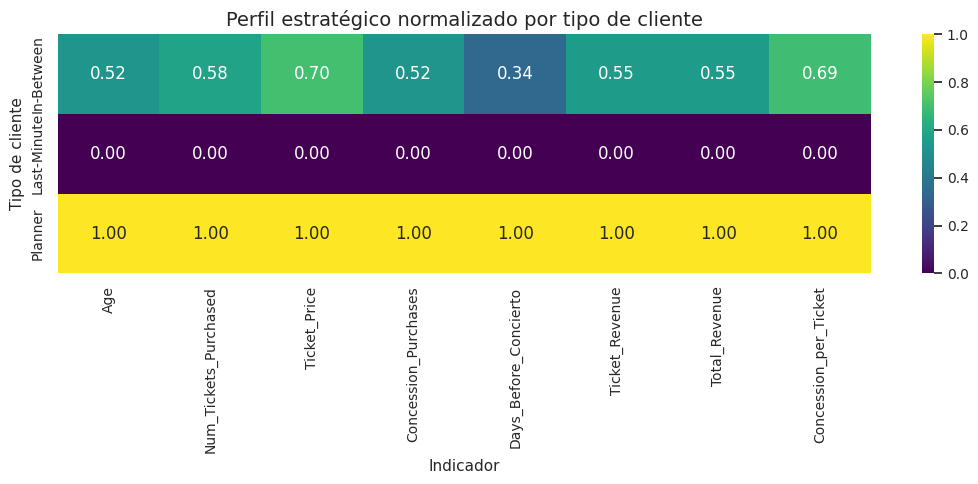

In [22]:
# ============================================================
# 21. Perfil estratégico por tipo de cliente
# ============================================================

if "Customer_Type" in df.columns:
    segment_metrics = [
        c for c in [
            "Age", "Num_Tickets_Purchased", "Ticket_Price", "Concession_Purchases",
            "Days_Before_Concierto", "Ticket_Revenue", "Total_Revenue", "Concession_per_Ticket"
        ] if c in df.columns
    ]

    segment_profile = (
        df.groupby("Customer_Type", observed=False)[segment_metrics]
        .mean(numeric_only=True)
        .reset_index()
    )

    display(segment_profile)

    segment_long = segment_profile.melt(
        id_vars="Customer_Type",
        var_name="Indicador",
        value_name="Promedio"
    )

    # Normalización min-max solo para comparar perfiles en el gráfico radial/heatmap
    heatmap_data = segment_profile.set_index("Customer_Type").copy()
    heatmap_scaled = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

    plt.figure(figsize=(11, 5))
    sns.heatmap(heatmap_scaled, annot=True, fmt=".2f", cmap="viridis")
    plt.title("Perfil estratégico normalizado por tipo de cliente")
    plt.xlabel("Indicador")
    plt.ylabel("Tipo de cliente")
    plt.tight_layout()
    plt.show()

# 17. Matriz de prioridad gerencial

Esta matriz cruza dos dimensiones:

- **Valor económico:** ingreso total promedio.
- **Volumen:** número de registros/clientes.

La matriz ayuda a priorizar segmentos, conciertos o ubicaciones que combinan alto valor y alta escala.

,Concierto,volumen,ingreso_promedio,ingreso_total,tickets_promedio,anticipacion_promedio
56,6a746056e26b,12,"1,152.18","13,826.19",3.50,17.58
41,4b97f845624d,10,"1,379.48","13,794.84",4.30,16.70
79,9429b1e2cf58,12,"1,101.51","13,218.12",2.42,11.42
92,c235c4351211,15,836.71,"12,550.63",2.33,10.80
12,0f394c70b4c8,10,"1,214.30","12,143.00",3.60,14.40
...,...,...,...,...,...,...
112,e55640e5bb47,5,462.24,"2,311.20",1.40,8.40
98,cee00fadd776,3,710.71,"2,132.12",2.67,3.33
60,7040d6183039,4,311.88,"1,247.53",1.25,3.75
57,6c6defe33f66,2,580.38,"1,160.77",3.50,16.00


/tmp/ipykernel_2299/3657669588.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


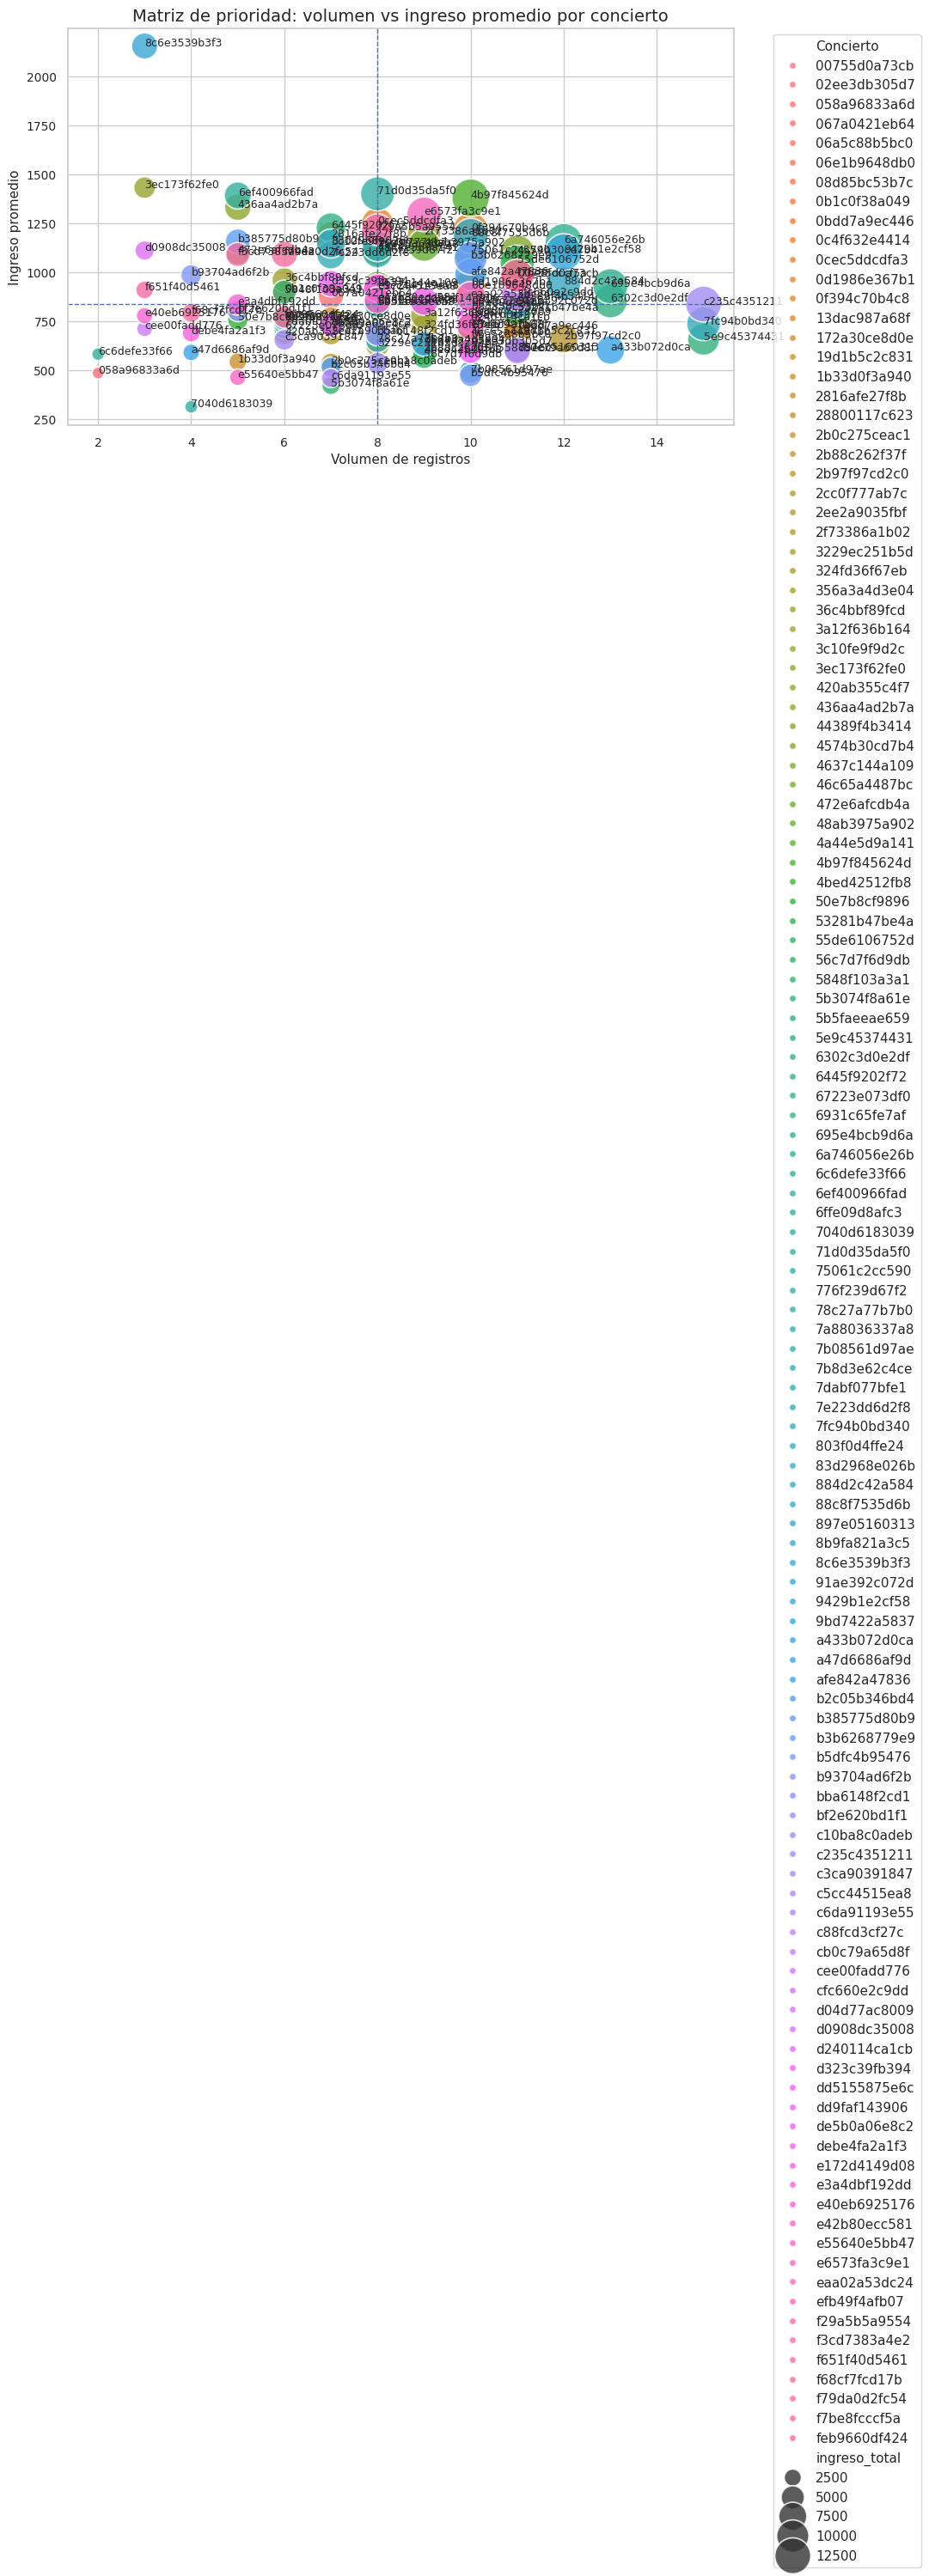

In [23]:
# ============================================================
# 22. Matriz de prioridad por concierto
# ============================================================

if {"Concierto", "Total_Revenue"}.issubset(df.columns):
    priority_concert = (
        df.groupby("Concierto", observed=False)
        .agg(
            volumen=("Concierto", "count"),
            ingreso_promedio=("Total_Revenue", "mean"),
            ingreso_total=("Total_Revenue", "sum"),
            tickets_promedio=("Num_Tickets_Purchased", "mean") if "Num_Tickets_Purchased" in df.columns else ("Total_Revenue", "mean"),
            anticipacion_promedio=("Days_Before_Concierto", "mean") if "Days_Before_Concierto" in df.columns else ("Total_Revenue", "mean")
        )
        .reset_index()
    )

    display(priority_concert.sort_values("ingreso_total", ascending=False))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=priority_concert,
        x="volumen",
        y="ingreso_promedio",
        size="ingreso_total",
        hue="Concierto",
        sizes=(100, 1000),
        alpha=0.8
    )

    for _, row in priority_concert.iterrows():
        plt.text(row["volumen"], row["ingreso_promedio"], str(row["Concierto"]), fontsize=9)

    plt.axvline(priority_concert["volumen"].median(), linestyle="--", linewidth=1)
    plt.axhline(priority_concert["ingreso_promedio"].median(), linestyle="--", linewidth=1)
    plt.title("Matriz de prioridad: volumen vs ingreso promedio por concierto")
    plt.xlabel("Volumen de registros")
    plt.ylabel("Ingreso promedio")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 18. Preguntas de discusión para clase

Con base en el EDA, los estudiantes deben responder:

1. ¿Qué segmentos parecen más relevantes para Movistar desde el punto de vista comercial?
2. ¿Qué conciertos concentran mayor ingreso total y cuáles tienen mejor ingreso promedio?
3. ¿La ubicación del asiento está asociada con mayor ingreso o consumo complementario?
4. ¿Los miembros del mailing list tienen comportamientos diferentes?
5. ¿Qué señales podrían considerarse atípicos valiosos y no errores?
6. ¿Qué variables deberían construirse antes de pasar a un modelo predictivo?
7. ¿Qué decisiones gerenciales se podrían tomar sin necesidad de entrenar todavía un modelo?

---

# 19. Conclusión metodológica

Este notebook muestra que la minería de datos comienza antes del Machine Learning.  
El valor inicial está en:

- Formular buenas preguntas de negocio.
- Diagnosticar la calidad de la base.
- Explorar patrones visualmente.
- Construir variables interpretables.
- Traducir resultados en decisiones gerenciales.

Solo después de esta etapa tendría sentido pasar a modelos como clasificación, segmentación automática o predicción de ingreso.

In [24]:
# ============================================================
# 23. Exportar base enriquecida para uso posterior
# ============================================================

output_path = "movistar_eda_enriquecida.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"Base enriquecida guardada como: {output_path}")

Base enriquecida guardada como: movistar_eda_enriquecida.csv
